# Task 1A: Custom CNN on MNIST

Training a custom CNN (≤ 50,000 parameters) on the standard MNIST dataset.

**Constraints:** max 3 conv layers, max 2 FC layers, ≤ 50 000 trainable params.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os, json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# --- Paths: same layout locally and on Colab (/content) ---
DATA_ROOT = os.path.join(os.getcwd(), 'data')
CMNIST_DATA_DIR = "/content/drive/MyDrive/MS AI/Semester_2/Deep_Learning__AI-600/Assignments/3/cmnist"
for _d in (DATA_ROOT, CMNIST_DATA_DIR, 'plots', 'outputs'):
    os.makedirs(_d, exist_ok=True)

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    print('Colab detected — use Runtime → Change runtime type → GPU for faster training.')
print(f'DATA_ROOT={DATA_ROOT}')
print(f'CMNIST_DATA_DIR={CMNIST_DATA_DIR}  ← put the three LMS .pt files here')


Colab detected — use Runtime → Change runtime type → GPU for faster training.
DATA_ROOT=/content/data
CMNIST_DATA_DIR=/content/drive/MyDrive/MS AI/Semester_2/Deep_Learning__AI-600/Assignments/3/cmnist  ← put the three LMS .pt files here


## Helper functions

In [4]:
# ---------------------------------------------------------------------------
# Reproducibility & device
# ---------------------------------------------------------------------------

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    if torch.cuda.is_available():
        d = torch.device('cuda')
        print(f'Using GPU: {torch.cuda.get_device_name(0)}')
        return d
    print('Using CPU (on Colab: Runtime → Change runtime type → GPU).')
    return torch.device('cpu')



In [5]:

set_seed(42)
device = get_device()
print(f'Device: {device}')

Using CPU (on Colab: Runtime → Change runtime type → GPU).
Device: cpu


In [6]:
# ---------------------------------------------------------------------------
# MNIST data
# ---------------------------------------------------------------------------

def get_mnist_loaders(batch_size=128, val_split=0.1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    full_train = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

    val_size = int(len(full_train) * val_split)
    train_size = len(full_train) - val_size
    train_ds, val_ds = random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

In [7]:
# ---------------------------------------------------------------------------
# Training / Evaluation
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [8]:
# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------

def plot_curves(train_vals, val_vals, ylabel, title, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(train_vals, label='Train')
    plt.plot(val_vals, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_filters(model, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    filters = model.features[0].weight.data.cpu()
    n_filters = filters.shape[0]
    n_channels = filters.shape[1]
    fig, axes = plt.subplots(1, n_filters, figsize=(n_filters * 2, 2))
    for i in range(n_filters):
        ax = axes[i] if n_filters > 1 else axes
        if n_channels == 1:
            ax.imshow(filters[i, 0], cmap='gray')
        else:
            f = filters[i].permute(1, 2, 0).numpy()
            f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f)
        ax.set_title(f'F{i}')
        ax.axis('off')
    plt.suptitle('First Conv Layer Filters')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


In [9]:
train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=128)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]

Train batches : 422
Val   batches : 47
Test  batches : 79


## MNIST

In [10]:
class MNISTNet(nn.Module):
    """Custom CNN for MNIST / C-MNIST classification.

    Architecture: 3 Conv layers + 2 FC layers, total params well under 50,000.
    Input sizes supported: 1×28×28 (MNIST) or 3×28×28 (C-MNIST).
    """

    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # After 3× pool-2 on 28×28: floor(28/2/2/2) = 3 → 32×3×3 = 288
        self.classifier = nn.Sequential(
            nn.Linear(32 * 3 * 3, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [11]:
# count parameters
def count_parameters(model):
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [12]:
model = MNISTNet(in_channels=1, num_classes=10).to(device)
n_params = count_parameters(model)
print(f'Total trainable parameters: {n_params:,}')
assert n_params <= 50_000, f'Parameter count {n_params} exceeds 50,000!'
print('Parameter constraint satisfied (<= 50,000)')
print(model)

Total trainable parameters: 25,034
Parameter constraint satisfied (<= 50,000)
MNISTNet(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=288, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f'Epoch {epoch:2d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

Epoch  1/15 | Train Loss: 0.3916  Acc: 0.8803 | Val Loss: 0.1279  Acc: 0.9627
Epoch  2/15 | Train Loss: 0.0957  Acc: 0.9700 | Val Loss: 0.0905  Acc: 0.9718
Epoch  3/15 | Train Loss: 0.0688  Acc: 0.9781 | Val Loss: 0.0694  Acc: 0.9780
Epoch  4/15 | Train Loss: 0.0549  Acc: 0.9827 | Val Loss: 0.0554  Acc: 0.9835
Epoch  5/15 | Train Loss: 0.0471  Acc: 0.9853 | Val Loss: 0.0569  Acc: 0.9825
Epoch  6/15 | Train Loss: 0.0390  Acc: 0.9876 | Val Loss: 0.0627  Acc: 0.9815
Epoch  7/15 | Train Loss: 0.0343  Acc: 0.9889 | Val Loss: 0.0504  Acc: 0.9847
Epoch  8/15 | Train Loss: 0.0306  Acc: 0.9899 | Val Loss: 0.0452  Acc: 0.9853
Epoch  9/15 | Train Loss: 0.0286  Acc: 0.9908 | Val Loss: 0.0443  Acc: 0.9878
Epoch 10/15 | Train Loss: 0.0239  Acc: 0.9922 | Val Loss: 0.0486  Acc: 0.9882
Epoch 11/15 | Train Loss: 0.0212  Acc: 0.9931 | Val Loss: 0.0440  Acc: 0.9868
Epoch 12/15 | Train Loss: 0.0190  Acc: 0.9941 | Val Loss: 0.0484  Acc: 0.9857
Epoch 13/15 | Train Loss: 0.0185  Acc: 0.9938 | Val Loss: 0.0448

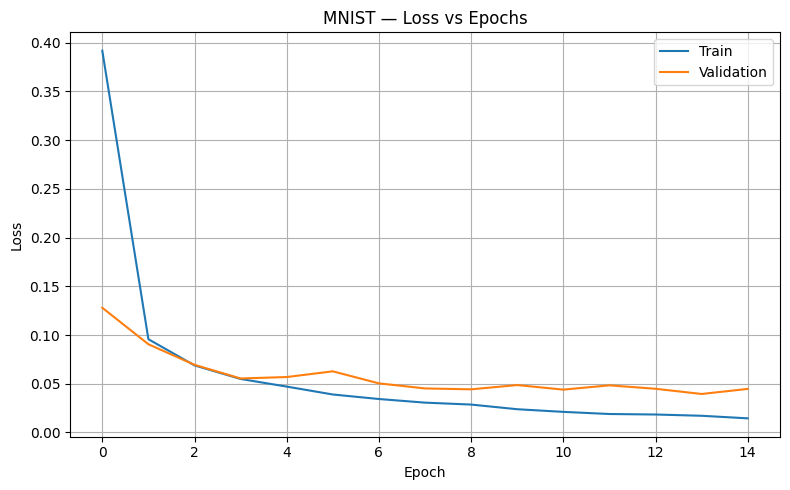

Saved: plots/mnist_loss.png


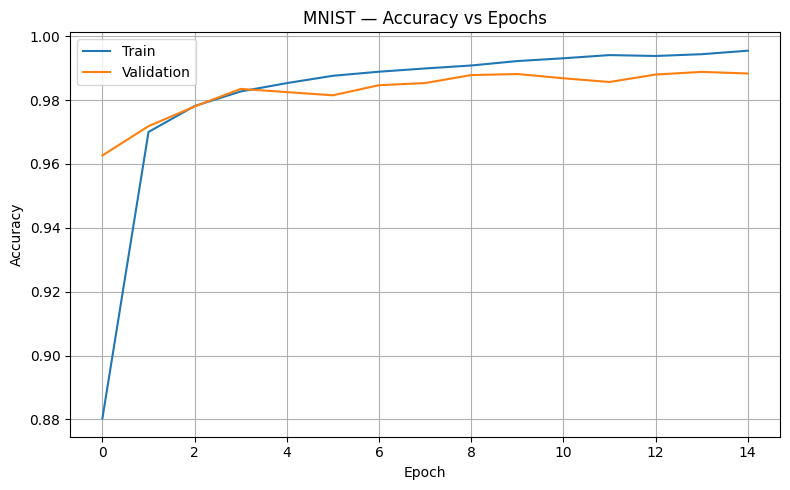

Saved: plots/mnist_accuracy.png


In [14]:
plot_curves(train_losses, val_losses,
            'Loss', 'MNIST — Loss vs Epochs',
            'plots/mnist_loss.png')
plot_curves(train_accs, val_accs,
            'Accuracy', 'MNIST — Accuracy vs Epochs',
            'plots/mnist_accuracy.png')

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss:     0.0341
Test Accuracy: 0.9897  (98.97%)


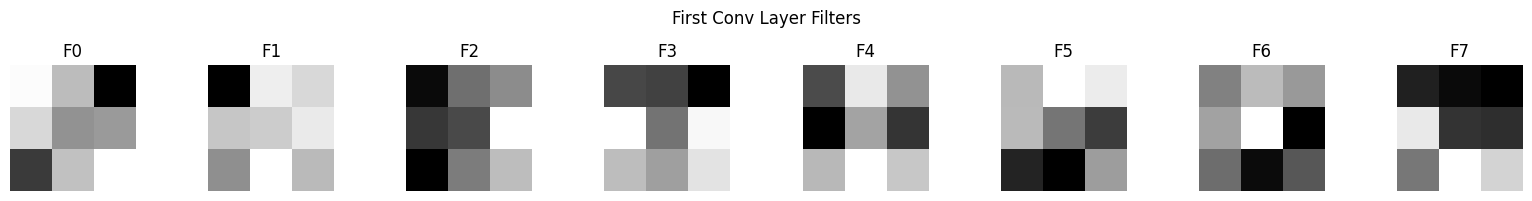

Saved: plots/mnist_filters.png


In [16]:
plot_filters(model, 'plots/mnist_filters.png')

In [17]:
results = dict(
    test_accuracy=test_acc, test_loss=test_loss,
    train_losses=train_losses, val_losses=val_losses,
    train_accs=train_accs, val_accs=val_accs,
    total_params=n_params, epochs=epochs,
)
os.makedirs('outputs', exist_ok=True)
with open('outputs/mnist_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to outputs/mnist_results.json')

Results saved to outputs/mnist_results.json


## Analysis

### Training Summary

The custom CNN has **25,034 trainable parameters** (well within the 50,000 limit). It converges
quickly — validation accuracy hits **96.3%** after epoch 1 and reaches **98.8%** by epoch 9.
By epoch 15, training accuracy is **99.55%** and validation accuracy is **98.83%**. The final
**test accuracy is 98.97%** with a test loss of 0.0341.

### Q1.1 — Overfitting, Underfitting, or Generalisation?

The model **generalises well**. The training loss drops steadily from 0.3916 to 0.0145 over
15 epochs, while the validation loss decreases from 0.1279 to ~0.044. The gap between them
remains small throughout:

- **Train accuracy**: 99.55% (epoch 15)
- **Val accuracy**: 98.83% (epoch 15)
- **Gap**: only ~0.7 percentage points

This narrow gap rules out significant overfitting. If the model were overfitting, we would see
the validation loss start increasing while the training loss kept decreasing — which does not
happen here (validation loss fluctuates slightly but never diverges upward). Conversely, if the
model were underfitting, both curves would plateau at high loss values with low accuracy. The
compact architecture (25,034 parameters) acts as an implicit regulariser for the relatively
simple MNIST task, keeping the model in the sweet spot of capacity.

### Q1.2 — Filter Interpretation

The 8 learned filters of the first convolutional layer (3×3, single-channel) show clear patterns:

- Several filters resemble **edge detectors** — they respond to horizontal, vertical, or
  diagonal intensity gradients, analogous to classical Gabor-like filters.
- Other filters act as **centre-surround operators** or **smoothing kernels**, capturing local
  contrast or averaging local regions.
- Some filters show **asymmetric weighting**, which helps detect oriented strokes and curves
  that distinguish digits (e.g. the loop in '0' vs. the vertical stroke in '1').

These low-level features are the building blocks that deeper layers compose into more complex
patterns (strokes, junctions, digit parts) to achieve the final 98.97% classification accuracy.

---

# Part B: Colored MNIST (C-MNIST)

Investigating **shortcut learning** by training on colour-biased MNIST data.

In [18]:
# ---------------------------------------------------------------------------
# Colored MNIST — LMS .pt files only (train_biased, test_biased, test_unbiased)
# ---------------------------------------------------------------------------

def _load_pt(path):
    """Load a .pt file and return (images, labels) tensors."""
    try:
        data = torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        data = torch.load(path, map_location='cpu')
    if isinstance(data, (list, tuple)):
        return data[0], data[1]
    if isinstance(data, dict):
        imgs = data.get('images', data.get('data', data.get('x')))
        lbls = data.get('labels', data.get('targets', data.get('y')))
        return imgs, lbls
    if isinstance(data, TensorDataset):
        return data.tensors[0], data.tensors[1]
    raise ValueError(f'Unknown .pt format in {path}: {type(data)}')


def _ensure_nchw(x):
    """If tensor is NHWC with 3 channels, convert to NCHW."""
    if x.dim() == 4 and x.shape[-1] in (1, 3) and x.shape[1] not in (1, 3):
        return x.permute(0, 3, 1, 2).contiguous()
    return x


def _scale_images_01(x):
    x = x.float()
    if x.numel() and float(x.max()) > 1.5:
        x = x / 255.0
    return x


def get_cmnist_loaders(data_dir='data/cmnist', batch_size=128):
    """Load C-MNIST from the three LMS .pt files in ``data_dir``."""
    pt_train  = os.path.join(data_dir, 'train_biased.pt')
    pt_biased = os.path.join(data_dir, 'test_biased.pt')
    pt_unbias = os.path.join(data_dir, 'test_unbiased.pt')
    missing = [p for p in (pt_train, pt_biased, pt_unbias) if not os.path.isfile(p)]
    if missing:
        raise FileNotFoundError(
            'C-MNIST .pt files not found. Expected in ' + os.path.abspath(data_dir) + ':\n'
            '  train_biased.pt, test_biased.pt, test_unbiased.pt\n'
            'Missing: ' + ', '.join(os.path.basename(m) for m in missing)
        )
    print(f'Loading C-MNIST from .pt files in {data_dir} ...')
    tr_imgs, tr_lbls = _load_pt(pt_train)
    bi_imgs, bi_lbls = _load_pt(pt_biased)
    ub_imgs, ub_lbls = _load_pt(pt_unbias)
    tr_imgs = _scale_images_01(_ensure_nchw(tr_imgs))
    bi_imgs = _scale_images_01(_ensure_nchw(bi_imgs))
    ub_imgs = _scale_images_01(_ensure_nchw(ub_imgs))
    tr_lbls, bi_lbls, ub_lbls = tr_lbls.long(), bi_lbls.long(), ub_lbls.long()
    print(f'  train : {tr_imgs.shape}  labels {tr_lbls.shape}')
    print(f'  biased: {bi_imgs.shape}  labels {bi_lbls.shape}')
    print(f'  unbias: {ub_imgs.shape}  labels {ub_lbls.shape}')
    return (
        DataLoader(TensorDataset(tr_imgs, tr_lbls),
                   batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(TensorDataset(bi_imgs, bi_lbls),
                   batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(TensorDataset(ub_imgs, ub_lbls),
                   batch_size=batch_size, shuffle=False, num_workers=0),
    )

In [19]:
# Uses CMNIST_DATA_DIR from the imports cell (data/cmnist under cwd)
data_dir = CMNIST_DATA_DIR
train_loader, test_biased_loader, test_unbiased_loader = get_cmnist_loaders(
    data_dir=data_dir, batch_size=128)

print(f'Train batches:          {len(train_loader)}')
print(f'Biased  test batches:   {len(test_biased_loader)}')
print(f'Unbiased test batches:  {len(test_unbiased_loader)}')

Loading C-MNIST from .pt files in /content/drive/MyDrive/MS AI/Semester_2/Deep_Learning__AI-600/Assignments/3/cmnist ...
  train : torch.Size([60000, 3, 28, 28])  labels torch.Size([60000])
  biased: torch.Size([10000, 3, 28, 28])  labels torch.Size([10000])
  unbias: torch.Size([10000, 3, 28, 28])  labels torch.Size([10000])
Train batches:          469
Biased  test batches:   79
Unbiased test batches:  79


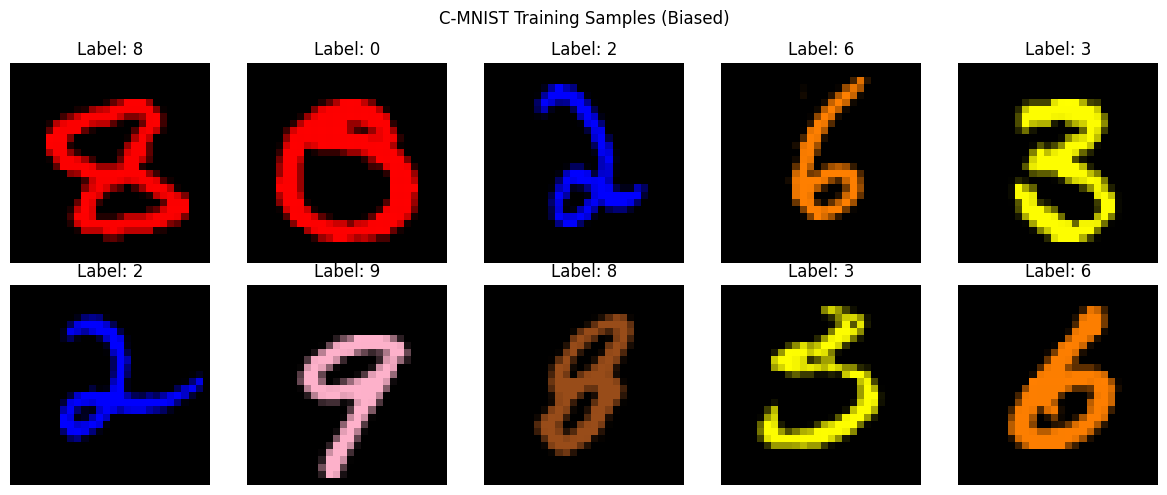

In [20]:
# Visualise a few training samples
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.suptitle('C-MNIST Training Samples (Biased)')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/cmnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
cmnist_model = MNISTNet(in_channels=3, num_classes=10).to(device)
cmnist_params = count_parameters(cmnist_model)
print(f'Total trainable parameters: {cmnist_params:,}')
assert cmnist_params <= 50_000, f'Parameter count {cmnist_params} exceeds 50,000!'
print('Parameter constraint satisfied (<= 50,000)')

Total trainable parameters: 25,178
Parameter constraint satisfied (<= 50,000)


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cmnist_model.parameters(), lr=1e-3)
epochs = 15

cmnist_train_losses, cmnist_val_losses = [], []
cmnist_train_accs, cmnist_val_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(cmnist_model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = evaluate(cmnist_model, test_biased_loader, criterion, device)
    cmnist_train_losses.append(tr_loss)
    cmnist_val_losses.append(vl_loss)
    cmnist_train_accs.append(tr_acc)
    cmnist_val_accs.append(vl_acc)
    print(f'Epoch {epoch:2d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Biased-Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

Epoch  1/15 | Train Loss: 0.4435  Acc: 0.8896 | Biased-Val Loss: 0.1260  Acc: 0.9679
Epoch  2/15 | Train Loss: 0.1033  Acc: 0.9718 | Biased-Val Loss: 0.0698  Acc: 0.9799
Epoch  3/15 | Train Loss: 0.0711  Acc: 0.9792 | Biased-Val Loss: 0.0695  Acc: 0.9791
Epoch  4/15 | Train Loss: 0.0537  Acc: 0.9843 | Biased-Val Loss: 0.0560  Acc: 0.9845
Epoch  5/15 | Train Loss: 0.0433  Acc: 0.9869 | Biased-Val Loss: 0.0399  Acc: 0.9880
Epoch  6/15 | Train Loss: 0.0367  Acc: 0.9894 | Biased-Val Loss: 0.0338  Acc: 0.9901
Epoch  7/15 | Train Loss: 0.0315  Acc: 0.9908 | Biased-Val Loss: 0.0407  Acc: 0.9888
Epoch  8/15 | Train Loss: 0.0270  Acc: 0.9917 | Biased-Val Loss: 0.0279  Acc: 0.9922
Epoch  9/15 | Train Loss: 0.0234  Acc: 0.9927 | Biased-Val Loss: 0.0318  Acc: 0.9903
Epoch 10/15 | Train Loss: 0.0230  Acc: 0.9931 | Biased-Val Loss: 0.0301  Acc: 0.9921
Epoch 11/15 | Train Loss: 0.0204  Acc: 0.9937 | Biased-Val Loss: 0.0255  Acc: 0.9921
Epoch 12/15 | Train Loss: 0.0189  Acc: 0.9943 | Biased-Val Loss: 

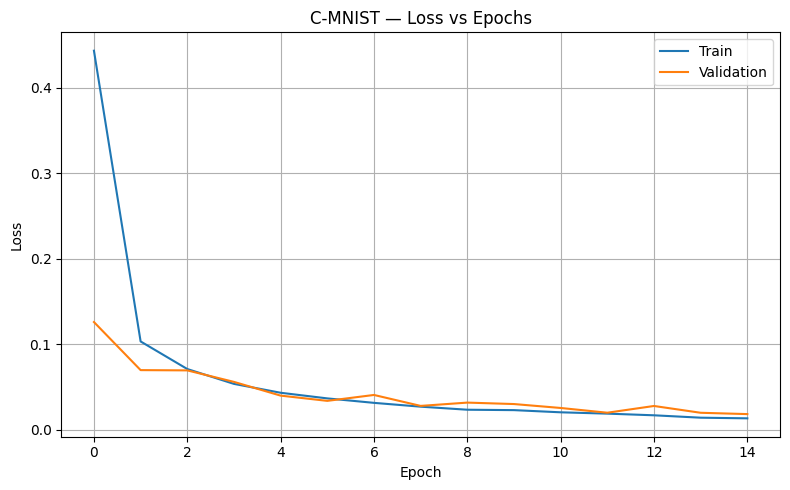

Saved: plots/cmnist_loss.png


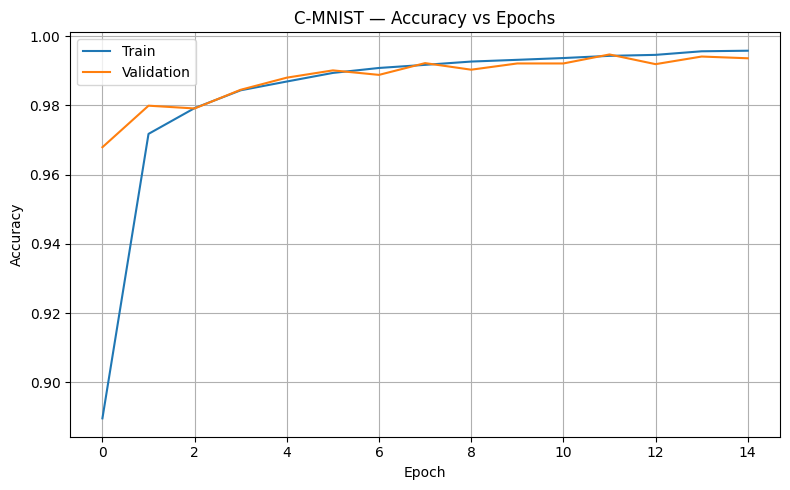

Saved: plots/cmnist_accuracy.png


In [23]:
plot_curves(cmnist_train_losses, cmnist_val_losses,
            'Loss', 'C-MNIST — Loss vs Epochs',
            'plots/cmnist_loss.png')
plot_curves(cmnist_train_accs, cmnist_val_accs,
            'Accuracy', 'C-MNIST — Accuracy vs Epochs',
            'plots/cmnist_accuracy.png')

In [24]:
_, biased_acc = evaluate(cmnist_model, test_biased_loader, criterion, device)
_, unbiased_acc = evaluate(cmnist_model, test_unbiased_loader, criterion, device)

print('=' * 55)
print('          C-MNIST  EVALUATION  RESULTS')
print('=' * 55)
print(f'  Biased   Test Accuracy : {biased_acc:.4f}  ({biased_acc*100:.2f}%)')
print(f'  Unbiased Test Accuracy : {unbiased_acc:.4f}  ({unbiased_acc*100:.2f}%)')
print(f'  Accuracy Drop          : {(biased_acc - unbiased_acc)*100:.2f}%')
print('=' * 55)

          C-MNIST  EVALUATION  RESULTS
  Biased   Test Accuracy : 0.9936  (99.36%)
  Unbiased Test Accuracy : 0.9315  (93.15%)
  Accuracy Drop          : 6.21%


In [25]:
cmnist_results = dict(
    biased_test_accuracy=biased_acc,
    unbiased_test_accuracy=unbiased_acc,
    accuracy_drop=biased_acc - unbiased_acc,
    train_losses=cmnist_train_losses, val_losses=cmnist_val_losses,
    train_accs=cmnist_train_accs, val_accs=cmnist_val_accs,
    total_params=cmnist_params, epochs=epochs,
)
os.makedirs('outputs', exist_ok=True)
with open('outputs/cmnist_results.json', 'w') as f:
    json.dump(cmnist_results, f, indent=2)
print('Results saved to outputs/cmnist_results.json')

Results saved to outputs/cmnist_results.json


## Analysis

### C-MNIST Training Summary

The 3-channel model has **25,178 trainable parameters** (still under 50,000). Training on the
biased C-MNIST dataset, it reaches **99.58% training accuracy** and **99.36% biased-validation
accuracy** by epoch 15 — nearly identical to grayscale MNIST performance.

| Test Set | Accuracy |
|----------|----------|
| Biased   | **99.36%** |
| Unbiased | **93.15%** |
| **Drop** | **6.21 pp** |

### Q1.3 — Why does accuracy drop on the unbiased test set?

The model achieves **99.36%** on the biased test set but drops to **93.15%** on the unbiased
test set — a **6.21 percentage-point gap**. This happens because the model partially exploits
the spurious colour–label correlation present in training:

- In the biased training set, each digit class is assigned a specific colour with high
  probability, making the mutual information $I(\text{colour};\,\text{label})$ very high.
- Colour is a **simpler feature** than shape — it can be detected by the first convolutional
  layer alone through per-channel mean activations. Gradient descent naturally converges toward
  this easier signal first.
- On the **unbiased** test set, colours are randomised and no longer predict the label. The
  colour-dependent features become noise, degrading accuracy.

The drop of 6.21% (rather than a collapse to ~10% chance) indicates the model learned **both**
colour and shape features to some degree. The shape pathway still provides 93% accuracy, but
the colour shortcut inflated the biased-test performance by ~6 points.

### Q1.4 — Strategies to avoid shortcut learning

1. **Colour jittering / augmentation** during training to break the colour–label link so the
   model cannot rely on a consistent colour-to-class mapping.
2. **Grayscale conversion** of inputs, eliminating the colour channel entirely and forcing the
   model to rely on shape.
3. **Invariant Risk Minimisation (IRM)** — train across multiple environments with different
   spurious correlations so that only the invariant (shape) feature survives.
4. **Balanced sampling** — ensure every digit class sees every colour equally during training,
   making colour uninformative by construction.
5. **Adversarial debiasing** — add a gradient-reversal branch that tries to predict colour;
   penalising the main network for encoding colour information.